In [1]:
import json
import numpy as np
import os

# Import your neural network classes
from cpg_rbf.cpg_so2 import CPG_SO2
from cpg_rbf.rbf import RBF

# ==========================================
# 1. CONFIGURATION
# ==========================================
gait = "water_surface"  

# Path to the target trajectory you recorded earlier
TRAJ_FILE = f"learned_weight_set/{gait}/target_trajectory.json"

# Path where the newly learned weights will be saved
WEIGHTS_FILE = f"learned_weight_set/{gait}/learned_weights.json"

CPG_PHI = 0.05
NUM_KERNELS = 20

def learn_and_save_weights(target_file, weights_file):
    print(f"Loading target trajectory from: {target_file}")
    
    # ==========================================
    # 2. LOAD TARGET DATA
    # ==========================================
    try:
        with open(target_file, "r") as f:
            target_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: Target file '{target_file}' not found.")
        return

    # Automatically detect the length of the CPG cycle from the data
    cpg_cycle_length = len(next(iter(target_data.values())))
    print(f"Detected CPG cycle length: {cpg_cycle_length} steps")

    # ==========================================
    # 3. INITIALIZE CPG & RBF NETWORKS
    # ==========================================
    print("Initializing CPG and RBF networks...")
    cpg = CPG_SO2()
    rbf = RBF(nc=NUM_KERNELS)
    
    # Generate CPG signals for exactly one cycle
    cpg_one_cycle = cpg.generate_cpg_one_cycle(CPG_PHI)
    out0 = cpg_one_cycle['out0_cpg_one_cycle'][:cpg_cycle_length]
    out1 = cpg_one_cycle['out1_cpg_one_cycle'][:cpg_cycle_length]
    
    # Construct the normalized RBF kernels
    rbf.construct_kernels_with_cpg_one_cycle(out0, out1, cpg_cycle_length)
    
    learned_weights = {}

    # ==========================================
    # 4. IMITATE TRAJECTORY (LEARNING)
    # ==========================================
    print("\nLearning weights for each joint...")
    for actuator_name, trajectory in target_data.items():
        
        # 1. The trajectory is a Python list from JSON, convert it to a NumPy array
        target_array = np.array(trajectory)
        
        # 2. Execute RBF imitation learning
        rbf.imitate_path_by_learning(target_array)
        
        # 3. Extract the optimized weights
        weights = rbf.get_rbf_weight()
        
        # 4. Map MuJoCo name (e.g., 'FR_J1') back to weight name (e.g., 'FR0')
        leg_prefix = actuator_name.split('_')[0]
        joint_idx = int(actuator_name.split('J')[1]) - 1
        weight_key = f"{leg_prefix}{joint_idx}"
        
        # 5. Store in dictionary (must convert NumPy array to standard list for JSON)
        learned_weights[weight_key] = weights.tolist()
        
        print(f"  -> Learned perfectly: {actuator_name:7} (Saved as '{weight_key}')")

    # ==========================================
    # 5. SAVE WEIGHTS TO JSON
    # ==========================================
    # Ensure the target directory exists before saving
    os.makedirs(os.path.dirname(weights_file), exist_ok=True)
    
    with open(weights_file, "w") as f:
        # Use indent=4 to make the JSON file highly readable
        json.dump(learned_weights, f, indent=4)
        
    print(f"\n✅ Successfully learned and saved {len(learned_weights)} weight sets to:")
    print(f"   {weights_file}")
    print("   You can now run your Matplotlib script to visualize the overlap!")

if __name__ == "__main__":
    learn_and_save_weights(TRAJ_FILE, WEIGHTS_FILE)

Loading target trajectory from: learned_weight_set/water_surface/target_trajectory.json
Detected CPG cycle length: 127 steps
Initializing CPG and RBF networks...

Learning weights for each joint...
last iteration: 286
  -> Learned perfectly: FR_J1   (Saved as 'FR0')
last iteration: 137
  -> Learned perfectly: FR_J2   (Saved as 'FR1')
last iteration: 244
  -> Learned perfectly: FR_J3   (Saved as 'FR2')
last iteration: 104
  -> Learned perfectly: FR_J4   (Saved as 'FR3')
last iteration: 150
  -> Learned perfectly: BR_J1   (Saved as 'BR0')
last iteration: 188
  -> Learned perfectly: BR_J2   (Saved as 'BR1')
last iteration: 197
  -> Learned perfectly: BR_J3   (Saved as 'BR2')
last iteration: 231
  -> Learned perfectly: BR_J4   (Saved as 'BR3')
last iteration: 218
  -> Learned perfectly: FL_J1   (Saved as 'FL0')
last iteration: 237
  -> Learned perfectly: FL_J2   (Saved as 'FL1')
last iteration: 458
  -> Learned perfectly: FL_J3   (Saved as 'FL2')
last iteration: 175
  -> Learned perfectly:

Loading data...
Regenerating learned trajectories through RBF network...
Generating plot...


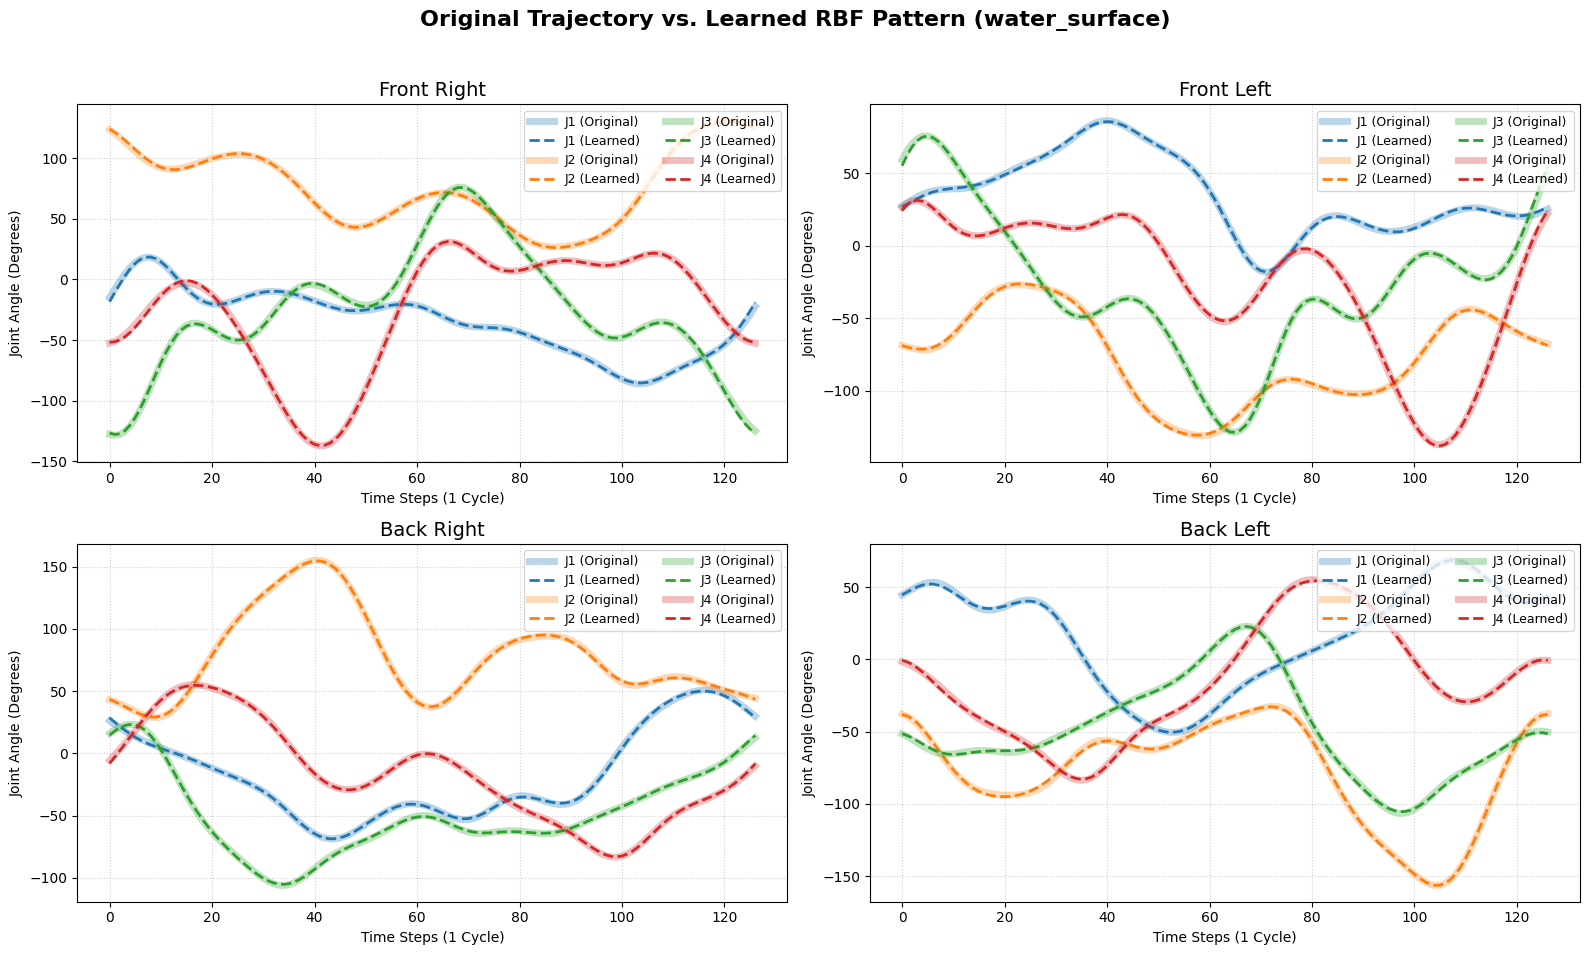

In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Import your neural network classes
from cpg_rbf.cpg_so2 import CPG_SO2
from cpg_rbf.rbf import RBF

# ==========================================
# 1. CONFIGURATION
# ==========================================
CPG_PHI = 0.05
NUM_KERNELS = 20

def plot_learning_accuracy(target_file, weights_file):
    print("Loading data...")
    
    # ==========================================
    # 2. LOAD FILES
    # ==========================================
    try:
        with open(target_file, "r") as f:
            target_data = json.load(f)
        with open(weights_file, "r") as f:
            learned_weights = json.load(f)
    except FileNotFoundError as e:
        print(f"Error: Could not find file. {e}")
        return

    cpg_cycle_length = len(next(iter(target_data.values())))
    time_steps = np.arange(cpg_cycle_length)

    # ==========================================
    # 3. REGENERATE LEARNED TRAJECTORIES
    # ==========================================
    print("Regenerating learned trajectories through RBF network...")
    cpg = CPG_SO2()
    rbf = RBF(nc=NUM_KERNELS)
    
    # Generate CPG signals
    cpg_one_cycle = cpg.generate_cpg_one_cycle(CPG_PHI)
    out0 = cpg_one_cycle['out0_cpg_one_cycle'][:cpg_cycle_length]
    out1 = cpg_one_cycle['out1_cpg_one_cycle'][:cpg_cycle_length]
    
    # Construct Kernels
    rbf.construct_kernels_with_cpg_one_cycle(out0, out1, cpg_cycle_length)
    
    generated_trajectories = {}
    
    for actuator_name in target_data.keys():
        # Map target name ('FR_J1') to weight name ('FR0')
        leg_prefix = actuator_name.split('_')[0]
        joint_idx = int(actuator_name.split('J')[1]) - 1
        weight_key = f"{leg_prefix}{joint_idx}"
        
        if weight_key in learned_weights:
            # Convert JSON list back to numpy array
            weights = np.array(learned_weights[weight_key])
            
            # 🚨 THE FIX: Loop through time step-by-step instead of passing the whole array 
            learned_path = []
            for t in range(cpg_cycle_length):
                angle = rbf.regenerate_target_traj(out0[t], out1[t], weights)
                learned_path.append(angle)
                
            generated_trajectories[actuator_name] = learned_path
    # ==========================================
    # 4. PLOT TARGET VS. LEARNED
    # ==========================================
    print("Generating plot...")
    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"Original Trajectory vs. Learned RBF Pattern ({gait})", fontsize=16, fontweight='bold')

    # Grid mapping for the 4 legs
    legs = [
        ('FR', 'Front Right', axs[0, 0]),
        ('FL', 'Front Left',  axs[0, 1]),
        ('BR', 'Back Right',  axs[1, 0]),
        ('BL', 'Back Left',   axs[1, 1])
    ]
    
    joints = ['J1', 'J2', 'J3', 'J4']
    colors = {'J1': '#1f77b4', 'J2': '#ff7f0e', 'J3': '#2ca02c', 'J4': '#d62728'} # Distinct colors

    for leg_prefix, leg_title, ax in legs:
        ax.set_title(leg_title, fontsize=14)
        
        for joint in joints:
            actuator_name = f"{leg_prefix}_{joint}"
            color = colors[joint]
            
            # Plot Original Target (Thick, semi-transparent solid line)
            if actuator_name in target_data:
                target_deg = np.degrees(target_data[actuator_name])
                ax.plot(time_steps, target_deg, color=color, linewidth=5, alpha=0.3, label=f"{joint} (Original)")
            
            # Plot Learned Pattern (Thin, dashed line)
            if actuator_name in generated_trajectories:
                learned_deg = np.degrees(generated_trajectories[actuator_name])
                ax.plot(time_steps, learned_deg, color=color, linewidth=2, linestyle='--', label=f"{joint} (Learned)")

        # Grid and Labels
        ax.set_xlabel("Time Steps (1 Cycle)")
        ax.set_ylabel("Joint Angle (Degrees)")
        ax.grid(True, linestyle=':', alpha=0.6)
        
        # Consolidate legend (remove duplicates)
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=9, ncol=2)

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.show()

if __name__ == "__main__":
    plot_learning_accuracy(TRAJ_FILE, WEIGHTS_FILE)